# Showcase of Tensorboard capabilities


In [266]:
from torch import nn
import torch
import numpy as np
import matplotlib.pyplot as plt
import torchvision
from torchvision.transforms import v2
from tqdm import tqdm

In [267]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Launching on {device}")

Launching on cuda


In [268]:
def seed_everything(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(42)

In [269]:
def gen_convbatchrelu(in_channels, out_channels, kernel):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=kernel),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(),
    )


class CNN(nn.Module):
    def __init__(self, channels: list[int], kernels: list[int], output_size: int):
        super().__init__()

        out_flatten_size = 28 - sum(kernels) + len(kernels)

        self.conv_batchnorm_relu = nn.Sequential(
            *[
                gen_convbatchrelu(in_channels, out_channels, kernel)
                for (in_channels, out_channels, kernel) in zip(
                    channels[:-1], channels[1:], kernels
                )
            ]
        )

        self.clf = nn.Linear(channels[-1] * out_flatten_size**2, output_size)

    def forward(self, x):
        x = self.conv_batchnorm_relu(x)
        x = torch.flatten(x, 1, 3)
        out = self.clf(x)

        return out


In [270]:
model = CNN([1, 16, 16, 32], [7, 5, 3], 10)

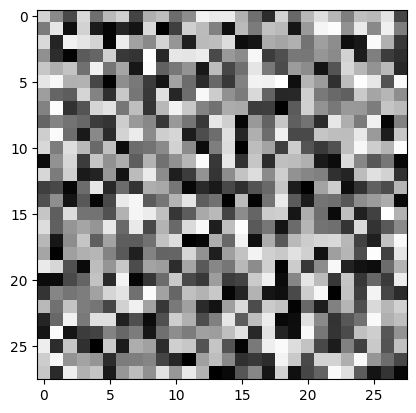

In [271]:
random_input = torch.randint(0, 255, (1, 1, 28, 28), dtype=torch.float)

plt.imshow(random_input.view((28, 28)).numpy(), cmap="gray")
plt.show()

In [272]:
model(random_input)
model.to(device)

CNN(
  (conv_batchnorm_relu): Sequential(
    (0): Sequential(
      (0): Conv2d(1, 16, kernel_size=(7, 7), stride=(1, 1))
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
    (1): Sequential(
      (0): Conv2d(16, 16, kernel_size=(5, 5), stride=(1, 1))
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
    (2): Sequential(
      (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
  )
  (clf): Linear(in_features=8192, out_features=10, bias=True)
)

In [273]:
n_epoches = 7
batch_size = 64
lr = 6e-4
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
loss_fn = nn.CrossEntropyLoss()

In [274]:
img_transform = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float)])

train_dataset = torchvision.datasets.MNIST(
    "datasets", transform=img_transform, download=True
)
val_dataset = torchvision.datasets.MNIST(
    "datasets", transform=img_transform, train=False
)

train_dataset[0][0].shape

torch.Size([1, 28, 28])

In [275]:
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = torch.utils.data.DataLoader(
    val_dataset, batch_size=batch_size, shuffle=False
)

In [276]:
from torch.utils.tensorboard import SummaryWriter

writer = SummaryWriter(f"runs/cnn_training/lr_{lr}/bs_{batch_size}")

for epoch in range(n_epoches):
    model.train()
    total = 0
    correct = 0
    running_loss = 0

    for name, param in model.named_parameters():
        writer.add_histogram(name, param, epoch)

    for imgs, targets in tqdm(train_loader):
        imgs, targets = imgs.to(device), targets.to(device)

        out = model(imgs)
        loss = loss_fn(out, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        preds = out.argmax(dim=1)
        correct += (preds == targets).sum().item()
        total += targets.size(0)

    train_loss = running_loss / len(train_loader)
    train_accuracy = correct / total

    print(f"Train Loss: {train_loss} Accuracy: {train_accuracy}")
    writer.add_scalar("Loss/train", train_loss, epoch)
    writer.add_scalar("Accuracy/train", train_accuracy, epoch)

    model.eval()
    total = 0
    correct = 0
    running_loss = 0

    with torch.no_grad():
        for imgs, targets in tqdm(val_loader):
            imgs, targets = imgs.to(device), targets.to(device)

            out = model(imgs)
            loss = loss_fn(out, targets)

            running_loss += loss.item()

            preds = out.argmax(dim=1)
            correct += (preds == targets).sum().item()
            total += targets.size(0)

    val_loss = running_loss / len(val_loader)
    val_accuracy = correct / total

    print(f"Val Loss: {val_loss} Accuracy: {val_accuracy}")
    writer.add_scalar("Loss/val", val_loss, epoch)
    writer.add_scalar("Accuracy/val", val_accuracy, epoch)

writer.close()

  0%|          | 0/938 [00:00<?, ?it/s]

100%|██████████| 938/938 [00:06<00:00, 135.67it/s]


Train Loss: 0.11800217063951571 Accuracy: 0.9640166666666666


100%|██████████| 157/157 [00:00<00:00, 165.49it/s]


Val Loss: 0.05100461856057388 Accuracy: 0.9837


...

Val Loss: 0.03712057035644862 Accuracy: 0.9897


100%|██████████| 938/938 [00:07<00:00, 132.56it/s]


Train Loss: 0.017433387685066914 Accuracy: 0.9944166666666666


100%|██████████| 157/157 [00:00<00:00, 165.91it/s]

Val Loss: 0.03492096721842532 Accuracy: 0.9903


## Training Results

After this training we may open TensorBoard by runnig next command:

```bash
tensorboard --logdir runs
```

It will show us several metrics over time:
- Train/Validation losses (`Scalars` section)
- Weights/biases changings over time (`Histograms` section)

Example of graphs for scalars: \
<img src="plots_of_scalars.png" width="600">
<img src="plots_of_losses.png" width="600">

Example of histograms: (Bias started from some random variable and moved to some new distribution) \
<img src="bias_moving.png" width="400"> <img src="weights_normalizing.png" width="400">

You may also change hyperparameters and watch what will happen! \
<img src="several_plots.png" width="700">

TensorBoard Histograms show the distribution of a tensor’s values (like weights or activations) over time, letting you track how they change during training and detect issues like vanishing/exploding gradients.

## Model Architecture Visuals

TensorBoard Architecture Graphs display the model’s computational graph, illustrating layers, operations, and tensor flows, which helps in understanding the structure and debugging connectivity issues.

<img src="final_cnn.png" alt="drawing" width="500"/>

In [288]:
writer = SummaryWriter("visuals/trained_cnn_architecture")

writer.add_graph(model, train_dataset[0][0].unsqueeze(0).to(device))

writer.close()

## Embeddings Visuals

TensorBoard Embeddings visualize high-dimensional data (e.g., word or feature embeddings) in 2D or 3D using techniques like t-SNE or PCA, helping you see patterns, clusters, or separations between classes.

In [ ]:
activations = []
images = []
labels = []


def hook_fn(module, input, output):
    # take output features
    activations.append(output.detach().cpu())


hook = model.clf.register_forward_hook(hook_fn)

model.eval()
with torch.no_grad():
    for imgs, targets in val_loader:
        imgs, targets = imgs.to(device), targets.to(device)

        out = model(imgs)

        images.append(imgs.cpu())
        labels.append(targets.cpu())

        if len(images) > 10:
            break

hook.remove()

features = torch.cat(activations, dim=0)
print(f"{features.size()}")
imgs = torch.cat(images, dim=0)
print(f"{imgs.size()}")
labels = torch.cat(labels, dim=0)
print(f"{labels.size()}")

features = features.view(features.size(0), -1)

features = features[:100]
imgs = imgs[:100]
labels = labels[:100]


writer = SummaryWriter("visuals/trained_cnn_embeddings")

writer.add_embedding(features, metadata=labels.tolist(), label_img=imgs)

writer.close()

torch.Size([704, 10])
torch.Size([704, 1, 28, 28])
torch.Size([704])


After this you may see in tensorboard such projection: \
<img src="sphered_projection.png" width="400">

(Don't forget to enable Spherize data or else you will see): \
<img src="projection.png" width="400">